<a href="https://colab.research.google.com/github/Rapsim/IPEO_DeepL_group15/blob/raph/explo.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

### code adapté de l'exo 9

In [1]:
COLAB = False

In [2]:
if COLAB:
    # Clone the repo !! only branch raph here !!
    !git clone -b raph --single-branch https://github.com/Rapsim/IPEO_DeepL_group15.git
    %cd IPEO_DeepL_group15

    # Install Python dependencies from the requirements file
    !pip install -r requirements.txt


In [3]:
if COLAB: 
    from google.colab import drive
    drive.mount("/content/drive")

    import os

    # Must match the folder created in Drive
    data_root = "/content/drive/MyDrive/IPEO_DeepL_data"
    s2_dir = os.path.join(data_root, "S2")
    labels_dir = os.path.join(data_root, "labels")

    print("S2 dir:", s2_dir)
    print("Labels dir:", labels_dir)
    print("Number of S2 files:", len([f for f in os.listdir(s2_dir) if f.endswith(".tif")]))
    print("Number of label files:", len([f for f in os.listdir(labels_dir) if f.endswith(".tif")]))


In [4]:
import os
import torch
from torch.utils.data import dataset
from torch.utils.data import DataLoader
import numpy as np
import tifffile


In [5]:
device = 'cuda' if torch.cuda.is_available() else 'cpu'
print(device)

cpu


### Process classes from csv

In [6]:
import pandas as pd
import os
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap
import numpy as np

# Load the CSV with label codes
csv_path = os.path.join("data", "Codigos-da-legenda-colecao-9.csv")
label_df = pd.read_csv(csv_path, delimiter='\t')

# Number of classes: 37 from CSV + 1 for "no data" (class 0)
NUM_CLASSES = len(label_df) + 1  # = 38
print(f"Number of classes: {NUM_CLASSES} (including class 0 for 'no data')")

# Create custom colormap from the CSV, including black for class 0
class_colors = [(0, 0, 0)]  # Black for "no data" (class 0)
class_names = ['No Data']
class_ids = [0]

for _, row in label_df.iterrows():
    class_ids.append(row['Class_ID'])
    class_names.append(row['Description'])
    # Convert hex color to RGB (0-1 range)
    hex_color = row['Color'].lstrip('#')
    rgb = tuple(int(hex_color[i:i+2], 16)/255.0 for i in (0, 2, 4))
    class_colors.append(rgb)

# Create ListedColormap
custom_cmap = ListedColormap(class_colors)

# Print class info
print("\nClass mapping:")
for class_id, name in zip(class_ids, class_names):
    print(f"{class_id}: {name}")

Number of classes: 38 (including class 0 for 'no data')

Class mapping:
0: No Data
1: Forest
3: Forest Formation
4: Savanna Formation
5: Mangrove
6: Floodable Forest
49: Wooded Sandbank Vegetation
10: Herbaceous and Shrubby Vegetation
11: Wetland
12: Grassland
32:  Hypersaline Tidal Flat
29:  Rocky Outcrop
50:  Herbaceous Sandbank Vegetation
14:  Farming
15:  Pasture
18:  Agriculture
19:  Temporary Crop
39:  Soybean
20:  Sugar cane
40:  Rice
62:  Cotton (beta)
41:  Other Temporary Crops
36:  Perennial Crop
46:  Coffee
47:  Citrus
35:  Palm Oil
48:  Other Perennial Crops
9:  Forest Plantation
21:  Mosaic of Uses
22:  Non vegetated area
23:  Beach, Dune and Sand Spot
24:  Urban Area
30:  Mining
25:  Other non Vegetated Areas
26:  Water
33:  River, Lake and Ocean
31:  Aquaculture
27:  Not Observed


In [7]:
label_df.head()

,Class_ID,Level,Description,Descricao,Color
0,1,1,Forest,Floresta,#32a65e
1,3,2,Forest Formation,Formação Florestal,#1f8d49
2,4,2,Savanna Formation,Formação Savânica,#7dc975
3,5,2,Mangrove,Mangue,#04381d
4,6,2,Floodable Forest,Floresta Alagável,#026975


In [8]:
# Number of classes: 0 = nodata to 37 = last class in CSV ?
NUM_CLASSES = 38 # A ENLEVER !!!


In [9]:

if not COLAB:
    # If not in colab, for small tests
    data_root = "sample"

## Compute images mean and std

In [10]:
def compute_s2_mean_std(s2_dir, file_prefix="train"):
    s2_files = sorted(
        f for f in os.listdir(s2_dir)
        if f.startswith(file_prefix) and f.endswith(".tif")
    )
    
    sum_band = None
    sumsq_band = None
    total_pixels = 0

    for i, fname in enumerate(s2_files):
        path = os.path.join(s2_dir, fname)
        img = tifffile.imread(path).astype(np.float32)

        # ensure (C,H,W)
        if img.ndim == 2:
            img = img[np.newaxis, ...]
        elif img.ndim == 3 and img.shape[-1] in (12, 13):
            img = np.transpose(img, (2, 0, 1))  # (H,W,C)->(C,H,W)

        img = img / 10000.0  # scale to approx [0,1]
        C, H, W = img.shape

        if sum_band is None:
            sum_band = np.zeros(C, dtype=np.float64)
            sumsq_band = np.zeros(C, dtype=np.float64)

        flat = img.reshape(C, -1)
        sum_band += flat.sum(axis=1)
        sumsq_band += (flat**2).sum(axis=1)
        total_pixels += H * W

    mean = sum_band / total_pixels
    var = sumsq_band / total_pixels - mean**2
    std = np.sqrt(np.maximum(var, 1e-12))

    return mean, std

# Example: use on small training sample S2 folder 
# s2_dir_for_stats = "/content/drive/MyDrive/IPEO_DeepL_data/sample/S2" 
s2_dir_for_stats = "sample/S2" 
S2_MEAN, S2_STD = compute_s2_mean_std(s2_dir_for_stats, file_prefix="train")
print("S2_MEAN:", S2_MEAN)
print("S2_STD:", S2_STD)


S2_MEAN: [0.1139377  0.0890742  0.08113043 0.06680196 0.09717837 0.19016036
 0.23556764 0.2318273  0.27211989 0.05309604 0.18734722 0.08958261]
S2_STD: [0.00712784 0.01266245 0.01809968 0.03474503 0.03448118 0.03047756
 0.0388264  0.04093171 0.04471077 0.01083777 0.08132065 0.05494784]


### Trying faster version

In [11]:
import os
import numpy as np
import tifffile
from concurrent.futures import ThreadPoolExecutor
from functools import partial

def compute_s2_mean_std_fast(s2_dir, file_prefix="train", num_workers=4, sample_ratio=None):
    """
    Efficiently compute mean/std for large datasets.
    
    Args:
        s2_dir: directory containing .tif files
        file_prefix: filter files by prefix
        num_workers: parallel workers for I/O
        sample_ratio: if set (e.g., 0.1), only use 10% of files for estimation
    """
    s2_files = sorted(
        f for f in os.listdir(s2_dir)
        if f.startswith(file_prefix) and f.endswith(".tif")
    )
    
    # Optional: subsample for faster estimation
    if sample_ratio is not None and sample_ratio < 1.0:
        np.random.seed(42)
        n_samples = max(1, int(len(s2_files) * sample_ratio))
        s2_files = list(np.random.choice(s2_files, n_samples, replace=False))
    
    def process_file(fname):
        path = os.path.join(s2_dir, fname)
        # Read directly as float32 to avoid extra conversion
        img = tifffile.imread(path)
        
        # ensure (C,H,W)
        if img.ndim == 2:
            img = img[np.newaxis, ...]
        elif img.ndim == 3 and img.shape[-1] in (12, 13):
            img = np.moveaxis(img, -1, 0)  # faster than transpose
        
        C, H, W = img.shape
        n_pixels = H * W
        
        # Compute stats in float64 for precision, but read as original dtype
        # Scale factor applied during sum
        flat = img.reshape(C, -1).astype(np.float64) / 10000.0
        return flat.sum(axis=1), (flat**2).sum(axis=1), n_pixels, C
    
    # Parallel file reading
    with ThreadPoolExecutor(max_workers=num_workers) as executor:
        results = list(executor.map(process_file, s2_files))
    
    # Aggregate results
    C = results[0][3]
    sum_band = np.zeros(C, dtype=np.float64)
    sumsq_band = np.zeros(C, dtype=np.float64)
    total_pixels = 0
    
    for s, sq, n, _ in results:
        sum_band += s
        sumsq_band += sq
        total_pixels += n
    
    mean = sum_band / total_pixels
    var = sumsq_band / total_pixels - mean**2
    std = np.sqrt(np.maximum(var, 1e-12))
    
    return mean.astype(np.float32), std.astype(np.float32)

# Usage - full dataset
s2_dir_for_stats = "sample/S2"
S2_MEAN, S2_STD = compute_s2_mean_std_fast(s2_dir_for_stats, file_prefix="train", num_workers=4)

# Or use sampling for quick estimation on very large datasets
# S2_MEAN, S2_STD = compute_s2_mean_std_fast(s2_dir_for_stats, sample_ratio=0.1)

print("S2_MEAN:", S2_MEAN)
print("S2_STD:", S2_STD)

S2_MEAN: [0.11393778 0.0890742  0.08113038 0.06680197 0.09717833 0.19016032
 0.23556772 0.23182726 0.2721199  0.05309619 0.18734722 0.08958261]
S2_STD: [0.00712458 0.01266207 0.01809969 0.03474501 0.03448132 0.03047775
 0.03882572 0.04093163 0.0447105  0.01083702 0.08132052 0.05494786]


### dataset


In [12]:


class AmazonDataset(dataset.Dataset):
    """
    Custom Dataset class that loads Sentinel-2 image patches and
    land cover masks from your Amazon dataset.

    We keep the old name 'VaihingenDataset' so the rest of the
    notebook works without big changes.
    """

    def __init__(self, data_root, split="train"):
        """
        data_root: folder that contains the subfolders:
            data_root/S2/*.tif
            data_root/labels/*.tif

        split: "train", "val", or "test"
        """
        super().__init__()
        self.data_root = data_root
        self.split = split

        self.s2_dir = os.path.join(data_root, "S2")
        self.label_dir = os.path.join(data_root, "labels")

        # all filenames in S2 folder
        all_fnames = sorted(
            [f for f in os.listdir(self.s2_dir) if f.endswith(".tif")]
        )

        # separate train and test by prefix
        train_fnames = [f for f in all_fnames if f.startswith("train")]
        test_fnames  = [f for f in all_fnames if f.startswith("test")]

        if split in ("train", "val"):
            # deterministic 80/20 split of the train_ files
            n_train = int(0.8 * len(train_fnames))
            train_fnames = sorted(train_fnames)
            if split == "train":
                selected = train_fnames[:n_train]
            else:  # "val"
                selected = train_fnames[n_train:]
        elif split == "test":
            selected = sorted(test_fnames)
        else:
            raise ValueError(f"Unknown split: {split}")

        self.fnames = selected

        print(f"{split} split has {len(self.fnames)} samples.")

    def __len__(self):
        return len(self.fnames)

    def _read_tiff_image(self, path):
        """
        Read a .tif file as a numpy array and return it as (C, H, W).

        Works whether data is stored as (H, W, C) or (C, H, W) or (H, W).
        """
        arr = tifffile.imread(path)  # numpy array

        if arr.ndim == 2:
            # single band -> (1, H, W)
            arr = arr[np.newaxis, ...]
        elif arr.ndim == 3:
            # guess if channels are first or last
            if arr.shape[0] in (1, 3, 4, 12, 64):
                # assume (C, H, W)
                pass
            elif arr.shape[-1] in (1, 3, 4, 12, 64):
                # assume (H, W, C)
                arr = np.transpose(arr, (2, 0, 1))
            else:
                raise ValueError(f"Unexpected image shape {arr.shape} for {path}")
        else:
            raise ValueError(f"Unexpected ndim {arr.ndim} for {path}")

        return arr

    def __getitem__(self, idx):
        fname = self.fnames[idx]

        # Sentinel-2 image path and label path
        img_path = os.path.join(self.s2_dir, fname)
        label_path = os.path.join(self.label_dir, fname)

        # ---- Read Sentinel-2 patch ----
        img = self._read_tiff_image(img_path).astype(np.float32)  # (C, H, W)

        # Sentinel-2 typical values up to ~10000 -> scale to ~[0, 1]
        img = img / 10000.0

        img = torch.from_numpy(img)  # (C,H,W)

        if self.input_type == "S2":
            # apply per-band normalization using precomputed mean/std
            img = (img - self.S2_MEAN[:, None, None]) / self.S2_STD[:, None, None]

        # ---- Read label mask ----
        mask = tifffile.imread(label_path)  # often (H, W) or (1, H, W)

        if mask.ndim == 3:
            # squeeze if there is a singleton channel dimension
            if mask.shape[0] == 1:
                mask = mask[0]
            elif mask.shape[-1] == 1:
                mask = mask[..., 0]
            else:
                raise ValueError(f"Unexpected mask shape {mask.shape} for {label_path}")

        if mask.ndim != 2:
            raise ValueError(f"Mask must be 2D, got shape {mask.shape}")

        mask = mask.astype(np.int64)  # required for CrossEntropyLoss

        # ---- Convert to torch tensors ----
        inputs = torch.from_numpy(img)    # (C, H, W), C should be 12
        labels = torch.from_numpy(mask)   # (H, W), ints in [0..62] (0 = nodata)

        return inputs, labels


def load_dataloader(batch_size, split="train"):
    """
    split in {"train", "val", "test"}.

    The global variable `data_root` should point to the folder that
    contains the S2/ and labels/ folders.
    """
    return DataLoader(
        AmazonDataset(data_root, split=split),
        batch_size=batch_size,
        shuffle=(split == "train"),
        num_workers=2,
    )


### improvement test

In [13]:
class AmazonDataset(dataset.Dataset):
    """
    Custom Dataset class that loads Sentinel-2 image patches and
    land cover masks from your Amazon dataset.
    """

    def __init__(self, data_root, split="train", normalize=True):
        super().__init__()
        self.data_root = data_root
        self.split = split
        self.normalize = normalize
        
        # Convert global numpy arrays to torch tensors
        self.S2_MEAN = torch.tensor(S2_MEAN, dtype=torch.float32)
        self.S2_STD = torch.tensor(S2_STD, dtype=torch.float32)

        self.s2_dir = os.path.join(data_root, "S2")
        self.label_dir = os.path.join(data_root, "labels")

        all_fnames = sorted(
            [f for f in os.listdir(self.s2_dir) if f.endswith(".tif")]
        )

        train_fnames = [f for f in all_fnames if f.startswith("train")]
        test_fnames  = [f for f in all_fnames if f.startswith("test")]

        if split in ("train", "val"):
            n_train = int(0.8 * len(train_fnames))
            train_fnames = sorted(train_fnames)
            if split == "train":
                selected = train_fnames[:n_train]
            else:
                selected = train_fnames[n_train:]
        elif split == "test":
            selected = sorted(test_fnames)
        else:
            raise ValueError(f"Unknown split: {split}")

        self.fnames = selected
        print(f"{split} split has {len(self.fnames)} samples.")

    def __len__(self):
        return len(self.fnames)

    def _read_tiff_image(self, path):
        arr = tifffile.imread(path)
        if arr.ndim == 2:
            arr = arr[np.newaxis, ...]
        elif arr.ndim == 3:
            if arr.shape[0] in (1, 3, 4, 12, 13, 64):
                pass
            elif arr.shape[-1] in (1, 3, 4, 12, 13, 64):
                arr = np.transpose(arr, (2, 0, 1))
            else:
                raise ValueError(f"Unexpected image shape {arr.shape} for {path}")
        return arr

    def __getitem__(self, idx):
        fname = self.fnames[idx]
        img_path = os.path.join(self.s2_dir, fname)
        label_path = os.path.join(self.label_dir, fname)

        # Read Sentinel-2 patch
        img = self._read_tiff_image(img_path).astype(np.float32)
        img = img / 10000.0
        img = torch.from_numpy(img)

        # Apply normalization
        if self.normalize:
            img = (img - self.S2_MEAN[:, None, None]) / self.S2_STD[:, None, None]

        # Read label mask
        mask = tifffile.imread(label_path)
        if mask.ndim == 3:
            if mask.shape[0] == 1:
                mask = mask[0]
            elif mask.shape[-1] == 1:
                mask = mask[..., 0]

        labels = torch.from_numpy(mask.astype(np.int64))

        return img, labels

### Improvement V2 with class remapping

In [34]:
class AmazonDataset(dataset.Dataset):
    """
    Custom Dataset class that loads Sentinel-2 image patches and
    land cover masks from your Amazon dataset with class remapping.
    """

    def __init__(self, data_root, split="train", normalize=True):
        super().__init__()
        self.data_root = data_root
        self.split = split
        self.normalize = normalize
        
        # Convert global numpy arrays to torch tensors
        self.S2_MEAN = torch.tensor(S2_MEAN, dtype=torch.float32)
        self.S2_STD = torch.tensor(S2_STD, dtype=torch.float32)
        
        # Store the class mapping
        self.class_id_to_index = class_id_to_index
        self.index_to_class_id = index_to_class_id
        self.valid_classes = set(class_id_to_index.keys())

        self.s2_dir = os.path.join(data_root, "S2")
        self.label_dir = os.path.join(data_root, "labels")

        all_fnames = sorted(
            [f for f in os.listdir(self.s2_dir) if f.endswith(".tif")]
        )

        train_fnames = [f for f in all_fnames if f.startswith("train")]
        test_fnames  = [f for f in all_fnames if f.startswith("test")]

        if split in ("train", "val"):
            n_train = int(0.8 * len(train_fnames))
            train_fnames = sorted(train_fnames)
            if split == "train":
                selected = train_fnames[:n_train]
            else:
                selected = train_fnames[n_train:]
        elif split == "test":
            selected = sorted(test_fnames)
        else:
            raise ValueError(f"Unknown split: {split}")

        # Filter out images containing invalid classes
        print(f"Filtering {split} images to only include valid classes...")
        valid_fnames = []
        for fname in selected:
            label_path = os.path.join(self.label_dir, fname)
            mask = tifffile.imread(label_path)
            if mask.ndim == 3:
                if mask.shape[0] == 1:
                    mask = mask[0]
                elif mask.shape[-1] == 1:
                    mask = mask[..., 0]
            
            unique_classes = set(np.unique(mask).tolist())
            # Only keep image if ALL its classes are valid
            if unique_classes.issubset(self.valid_classes):
                valid_fnames.append(fname)
        
        self.fnames = valid_fnames
        print(f"{split} split has {len(self.fnames)} valid samples (filtered from {len(selected)} total).")


    def __len__(self):
        return len(self.fnames)

    def _read_tiff_image(self, path):
        arr = tifffile.imread(path)
        if arr.ndim == 2:
            arr = arr[np.newaxis, ...]
        elif arr.ndim == 3:
            if arr.shape[0] in (1, 3, 4, 12, 13, 64):
                pass
            elif arr.shape[-1] in (1, 3, 4, 12, 13, 64):
                arr = np.transpose(arr, (2, 0, 1))
            else:
                raise ValueError(f"Unexpected image shape {arr.shape} for {path}")
        return arr

    def __getitem__(self, idx):
        fname = self.fnames[idx]
        img_path = os.path.join(self.s2_dir, fname)
        label_path = os.path.join(self.label_dir, fname)

        # Read Sentinel-2 patch
        img = self._read_tiff_image(img_path).astype(np.float32)
        img = img / 10000.0
        img = torch.from_numpy(img)

        # Apply normalization
        if self.normalize:
            img = (img - self.S2_MEAN[:, None, None]) / self.S2_STD[:, None, None]

        # Read label mask
        mask = tifffile.imread(label_path)
        if mask.ndim == 3:
            if mask.shape[0] == 1:
                mask = mask[0]
            elif mask.shape[-1] == 1:
                mask = mask[..., 0]

        # Remap class IDs to consecutive indices [0, NUM_CLASSES-1]
        mask_remapped = np.full_like(mask, -100, dtype=np.int64)  # Default to ignore
        for orig_id, new_idx in self.class_id_to_index.items():
            mask_remapped[mask == orig_id] = new_idx

        labels = torch.from_numpy(mask_remapped)

        return img, labels

### Visualise some images

Filtering train images to only include valid classes...
train split has 6 valid samples (filtered from 8 total).
Image tensor size: torch.Size([12, 47, 47])
Label tensor size: torch.Size([47, 47])
Unique labels in image: [0 3]


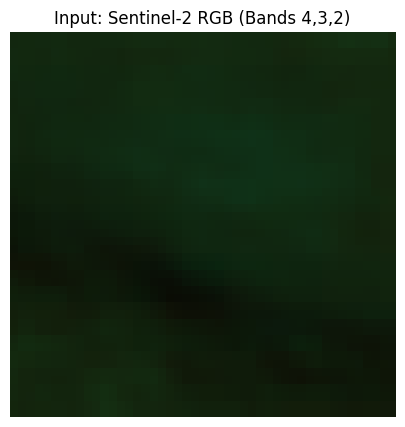

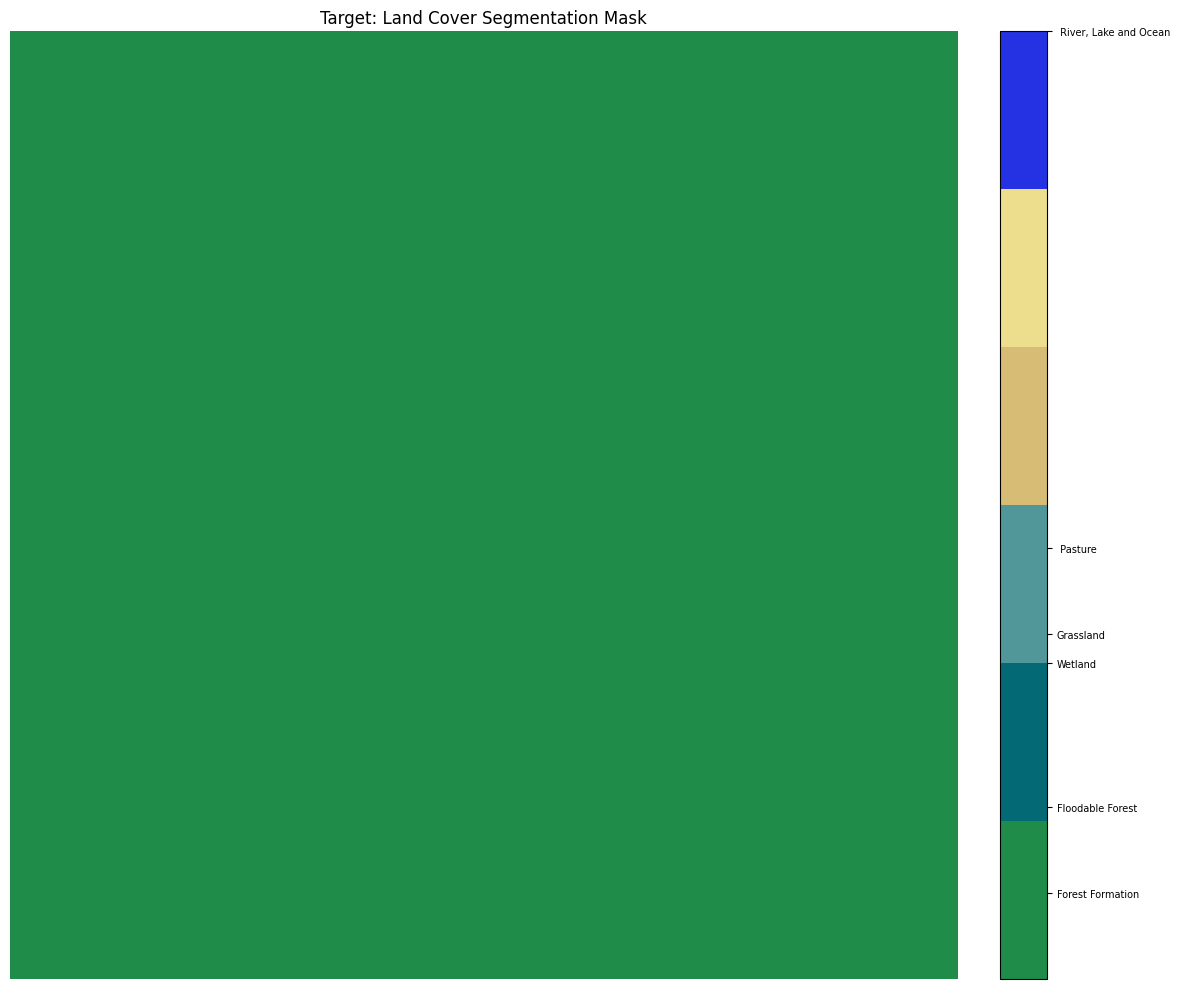

In [35]:
# Visualization with proper labels
dataset_train = AmazonDataset(data_root, split="train", normalize=False)

# draw a random sample
idx = torch.randint(0, len(dataset_train), (1,)).item()
data, target = dataset_train[idx]
print(f'Image tensor size: {data.size()}')
print(f'Label tensor size: {target.size()}')
print(f'Unique labels in image: {torch.unique(target).numpy()}')

# Visualize RGB (Sentinel-2 bands)
plt.figure(figsize=(10, 5))
# For Sentinel-2: bands [3,2,1] = RGB (Red, Green, Blue)
rgb = data[9:12, ...].permute(1, 2, 0).numpy()
plt.imshow(np.clip(rgb, 0, 1))
plt.title('Input: Sentinel-2 RGB (Bands 4,3,2)')
plt.axis('off')
plt.show()

# Visualize segmentation mask with custom colormap
fig, ax = plt.subplots(figsize=(12, 10))
im = ax.imshow(target.numpy(), cmap=custom_cmap, vmin=0, vmax=max(class_ids))
ax.axis('off')
ax.set_title('Target: Land Cover Segmentation Mask')

# Add colorbar with class names
cbar = fig.colorbar(im, ax=ax, ticks=class_ids, fraction=0.046, pad=0.04)
cbar.ax.set_yticklabels(class_names, fontsize=7)
plt.tight_layout()
plt.show()

## Handle class imbalance

### valid classes

In [36]:
import pandas as pd
import os
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap
import numpy as np
import tifffile

# Load the CSV with label codes
csv_path = os.path.join("data", "Codigos-da-legenda-colecao-9.csv")
label_df = pd.read_csv(csv_path, delimiter='\t')

# First, analyze class distribution in train and test sets
def get_classes_in_split(data_root, split_prefix):
    """Get all unique classes present in a split"""
    labels_dir = os.path.join(data_root, "labels")
    files = [f for f in os.listdir(labels_dir) if f.startswith(split_prefix) and f.endswith(".tif")]
    
    all_classes = set()
    for fname in files:
        label_path = os.path.join(labels_dir, fname)
        mask = tifffile.imread(label_path)
        unique_classes = np.unique(mask)
        all_classes.update(unique_classes.tolist())
    
    return all_classes

# Analyze class distribution
train_classes = get_classes_in_split(data_root, "train")
test_classes = get_classes_in_split(data_root, "test")

# Find valid classes (present in both splits)
valid_classes = train_classes.intersection(test_classes)
train_only_classes = train_classes - test_classes
test_only_classes = test_classes - train_classes

print(f"Classes in train only: {sorted(train_only_classes)}")
print(f"Classes in test only: {sorted(test_only_classes)}")
print(f"Valid classes (in both): {sorted(valid_classes)}")
print(f"Number of valid classes: {len(valid_classes)}")

# Update NUM_CLASSES to only include valid classes
NUM_CLASSES = len(valid_classes)
print(f"\nNUM_CLASSES (valid only): {NUM_CLASSES}")

# Create mapping for valid classes only
class_colors = []
class_names = []
class_ids = []

# Add class 0 if it's valid
if 0 in valid_classes:
    class_colors.append((0, 0, 0))
    class_names.append('No Data')
    class_ids.append(0)

# Add classes from CSV that are valid
for _, row in label_df.iterrows():
    if row['Class_ID'] in valid_classes:
        class_ids.append(row['Class_ID'])
        class_names.append(row['Description'])
        hex_color = row['Color'].lstrip('#')
        rgb = tuple(int(hex_color[i:i+2], 16)/255.0 for i in (0, 2, 4))
        class_colors.append(rgb)

# Create ListedColormap
custom_cmap = ListedColormap(class_colors)

print("\nValid class mapping:")
for class_id, name in zip(class_ids, class_names):
    print(f"{class_id}: {name}")

Classes in train only: [4, 18, 29]
Classes in test only: [9]
Valid classes (in both): [3, 6, 11, 12, 15, 33]
Number of valid classes: 6

NUM_CLASSES (valid only): 6

Valid class mapping:
3: Forest Formation
6: Floodable Forest
11: Wetland
12: Grassland
15:  Pasture
33:  River, Lake and Ocean


### Remap the valid class 
To avoid having unused channels output in the model

In [37]:
# Create bidirectional mapping from original class IDs to consecutive indices
valid_classes_sorted = sorted(valid_classes)
class_id_to_index = {class_id: idx for idx, class_id in enumerate(valid_classes_sorted)}
index_to_class_id = {idx: class_id for class_id, idx in class_id_to_index.items()}

# Update NUM_CLASSES to match number of valid classes
NUM_CLASSES = len(valid_classes)
print(f"\nNUM_CLASSES (remapped): {NUM_CLASSES}")

# Build remapped colormap and class names
class_colors_remapped = []
class_names_remapped = []
class_indices = list(range(NUM_CLASSES))  # [0, 1, 2, ..., NUM_CLASSES-1]

for new_idx in range(NUM_CLASSES):
    orig_class_id = index_to_class_id[new_idx]
    
    if orig_class_id == 0:
        class_colors_remapped.append((0, 0, 0))
        class_names_remapped.append('No Data')
    else:
        # Find in CSV
        row = label_df[label_df['Class_ID'] == orig_class_id].iloc[0]
        class_names_remapped.append(row['Description'])
        hex_color = row['Color'].lstrip('#')
        rgb = tuple(int(hex_color[i:i+2], 16)/255.0 for i in (0, 2, 4))
        class_colors_remapped.append(rgb)

# Create colormap for remapped classes
custom_cmap_remapped = ListedColormap(class_colors_remapped)

print("\nRemapped class mapping:")
print("New Index -> Original Class ID: Class Name")
for new_idx in range(NUM_CLASSES):
    orig_id = index_to_class_id[new_idx]
    print(f"{new_idx:2d} -> {orig_id:2d}: {class_names_remapped[new_idx]}")



NUM_CLASSES (remapped): 6

Remapped class mapping:
New Index -> Original Class ID: Class Name
 0 ->  3: Forest Formation
 1 ->  6: Floodable Forest
 2 -> 11: Wetland
 3 -> 12: Grassland
 4 -> 15:  Pasture
 5 -> 33:  River, Lake and Ocean


Filtering train images to only include valid classes...
train split has 6 valid samples (filtered from 8 total).
Image tensor size: torch.Size([12, 47, 47])
Label tensor size: torch.Size([47, 47])
Unique labels in image: [0 1]


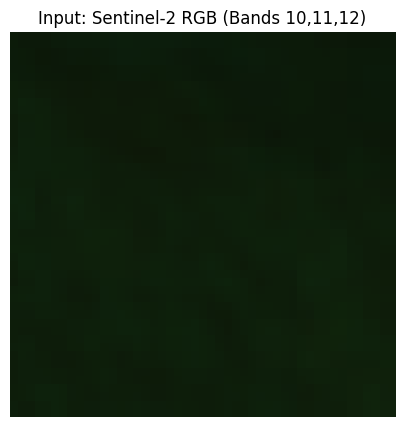

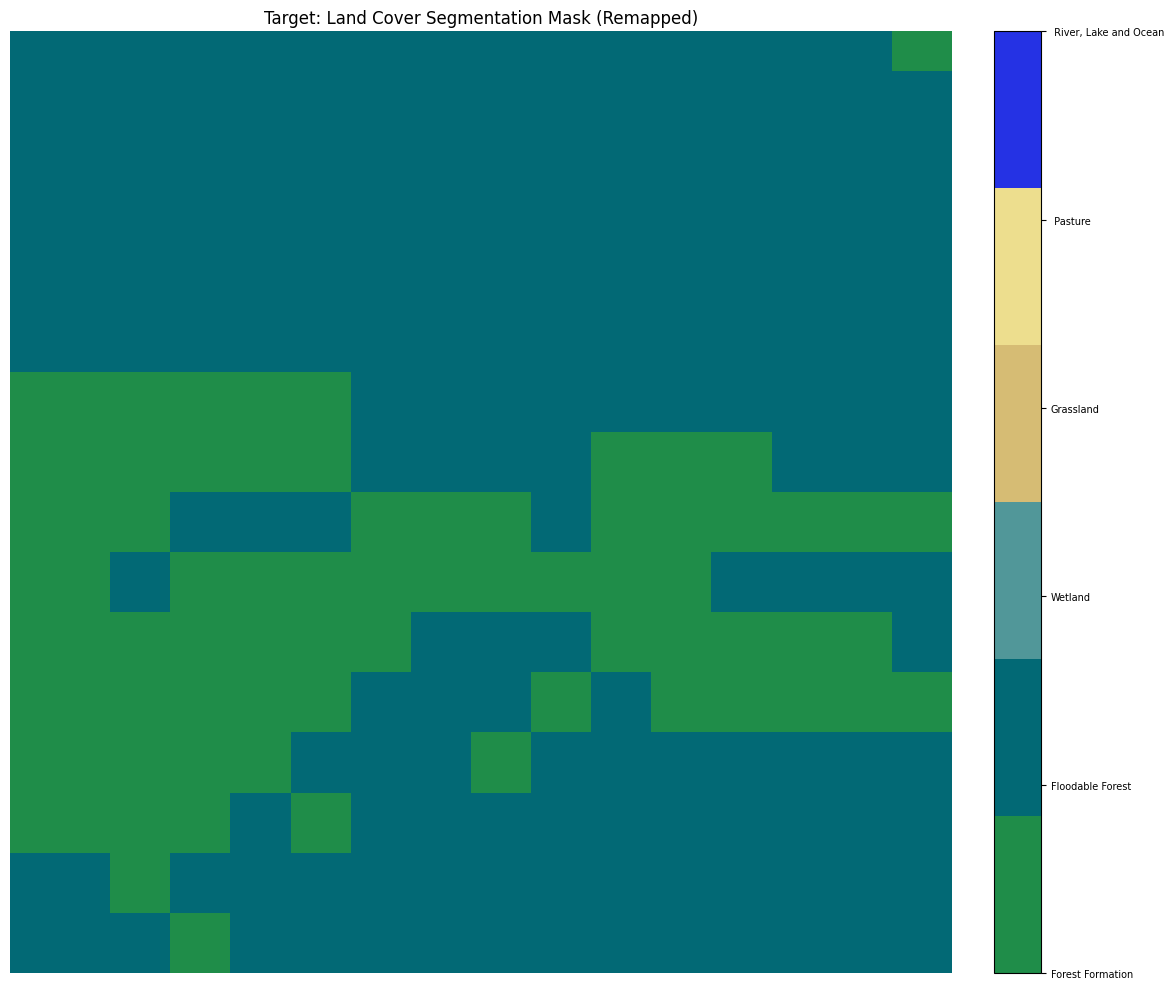

In [38]:
# Visualization with remapped labels
dataset_train = AmazonDataset(data_root, split="train", normalize=False)

# draw a random sample
idx = torch.randint(0, len(dataset_train), (1,)).item()
data, target = dataset_train[idx]
print(f'Image tensor size: {data.size()}')
print(f'Label tensor size: {target.size()}')
print(f'Unique labels in image: {torch.unique(target).numpy()}')

# Visualize RGB (Sentinel-2 bands)
plt.figure(figsize=(10, 5))
rgb = data[9:12, ...].permute(1, 2, 0).numpy()
plt.imshow(np.clip(rgb, 0, 1))
plt.title('Input: Sentinel-2 RGB (Bands 10,11,12)')
plt.axis('off')
plt.show()

# Visualize segmentation mask with remapped colormap
fig, ax = plt.subplots(figsize=(12, 10))
# Mask out -100 values for visualization
target_vis = target.numpy().copy()
target_vis[target_vis == -100] = 0  # Show as black
im = ax.imshow(target_vis, cmap=custom_cmap_remapped, vmin=0, vmax=NUM_CLASSES-1)
ax.axis('off')
ax.set_title('Target: Land Cover Segmentation Mask (Remapped)')

# Add colorbar with remapped class names
cbar = fig.colorbar(im, ax=ax, ticks=class_indices, fraction=0.046, pad=0.04)
cbar.ax.set_yticklabels(class_names_remapped, fontsize=7)
plt.tight_layout()
plt.show()

### Data loader

In [39]:
def load_dataloader(batch_size, split='train', normalize=True):
    """
    Creates a DataLoader for the Amazon dataset.
    
    Args:
        batch_size (int): Number of samples per batch
        split (str): One of 'train', 'val', or 'test'
        normalize (bool): Whether to apply normalization using S2_MEAN and S2_STD
    
    Returns:
        DataLoader: PyTorch DataLoader for the specified split
    """
    return DataLoader(
        AmazonDataset(data_root, split=split, normalize=normalize),
        batch_size=batch_size,
        shuffle=(split == 'train'),  # Only shuffle training data
        num_workers=0,                # Use 2 CPU threads for parallel data loading
    )

### Model: UNet

In [40]:
import torch
import torch.nn as nn
import torch.nn.functional as F

class DoubleConv(nn.Module):
    def __init__(self, in_ch, out_ch):
        super().__init__()
        self.net = nn.Sequential(
            nn.Conv2d(in_ch, out_ch, 3, padding=1),
            nn.BatchNorm2d(out_ch),
            nn.ReLU(inplace=True),
            nn.Conv2d(out_ch, out_ch, 3, padding=1),
            nn.BatchNorm2d(out_ch),
            nn.ReLU(inplace=True),
        )
    def forward(self, x): return self.net(x)

class UNet(nn.Module):
    def __init__(self, in_channels=12, num_classes=NUM_CLASSES, base=32):
        super().__init__()
        self.down1 = DoubleConv(in_channels, base)
        self.down2 = DoubleConv(base, base*2)
        self.down3 = DoubleConv(base*2, base*4)
        self.down4 = DoubleConv(base*4, base*8)
        self.pool  = nn.MaxPool2d(2)
        self.up3   = nn.ConvTranspose2d(base*8, base*4, 2, stride=2)
        self.conv3 = DoubleConv(base*8, base*4)
        self.up2   = nn.ConvTranspose2d(base*4, base*2, 2, stride=2)
        self.conv2 = DoubleConv(base*4, base*2)
        self.up1   = nn.ConvTranspose2d(base*2, base, 2, stride=2)
        self.conv1 = DoubleConv(base*2, base)
        self.out   = nn.Conv2d(base, num_classes, 1)

    def forward(self, x):
        d1 = self.down1(x)
        d2 = self.down2(self.pool(d1))
        d3 = self.down3(self.pool(d2))
        d4 = self.down4(self.pool(d3))
        
        u3 = self.up3(d4)
        # Match spatial dimensions before concatenation
        u3 = self._match_size(u3, d3)
        u3 = self.conv3(torch.cat([u3, d3], dim=1))
        
        u2 = self.up2(u3)
        u2 = self._match_size(u2, d2)
        u2 = self.conv2(torch.cat([u2, d2], dim=1))
        
        u1 = self.up1(u2)
        u1 = self._match_size(u1, d1)
        u1 = self.conv1(torch.cat([u1, d1], dim=1))
        
        return self.out(u1)
    
    def _match_size(self, x, target):
        """Pad or crop x to match target's spatial dimensions"""
        if x.shape[2:] != target.shape[2:]:
            x = F.interpolate(x, size=target.shape[2:], mode='bilinear', align_corners=False)
        return x

In [41]:
# use the model
dataloader_train = load_dataloader(batch_size=4, split="train", normalize=True)
model = UNet(in_channels=12, num_classes=NUM_CLASSES)
data,_ = iter(dataloader_train).__next__()
pred = model(data)

Filtering train images to only include valid classes...
train split has 6 valid samples (filtered from 8 total).


In [42]:
assert pred.size(1) == NUM_CLASSES, f'ERROR: invalid number of model output channels (should be # classes {len(dataset_train.LABEL_CLASSES)}, got {pred.size(1)})'
assert pred.size(2) == data.size(2), f'ERROR: invalid spatial height of model output (should be {data.size(2)}, got {pred.size(2)})'
assert pred.size(3) == data.size(3), f'ERROR: invalid spatial width of model output (should be {data.size(3)}, got {pred.size(3)})'

### Model training

In [43]:
criterion = nn.CrossEntropyLoss()
########### should use weighted loss here to handle class imbalance???

In [44]:
from torch.optim import SGD

def setup_optimiser(model, learning_rate, weight_decay):
  return SGD(
    model.parameters(),
    lr=learning_rate,
    weight_decay=weight_decay
  )

In [45]:
from tqdm.notebook import trange      # pretty progress bar

def train_epoch(data_loader, model, optimiser, device):

  # set model to training mode. This is important because some layers behave differently during training and testing
  model.train(True)
  model.to(device)

  # stats
  loss_total = 0.0
  oa_total = 0.0

  # iterate over dataset
  pBar = trange(len(data_loader))
  for idx, (data, target) in enumerate(data_loader):

    #TODO: implement the training step here. Check the introductory slides if you need help.

    # put data and target onto correct device
    data, target = data.to(device), target.to(device)

    # reset gradients
    optimiser.zero_grad()

    # forward pass
    pred = model(data)

    # loss
    loss = criterion(pred, target)

    # backward pass
    loss.backward()

    # parameter update
    optimiser.step()

    # stats update
    loss_total += loss.item()
    oa_total += torch.mean((pred.argmax(1) == target).float()).item()

    # format progress bar
    pBar.set_description('Loss: {:.2f}, OA: {:.2f}'.format(
      loss_total/(idx+1),
      100 * oa_total/(idx+1)
    ))
    pBar.update(1)
  
  pBar.close()

  # normalise stats
  loss_total /= len(data_loader)
  oa_total /= len(data_loader)

  return model, loss_total, oa_total

In [46]:

def validate_epoch(data_loader, model, device):       # note: no optimiser needed

  # set model to evaluation mode
  model.train(False)
  model.to(device)

  # stats
  loss_total = 0.0
  oa_total = 0.0

  # iterate over dataset
  pBar = trange(len(data_loader))
  for idx, (data, target) in enumerate(data_loader):
    with torch.no_grad():

      #TODO: likewise, implement the validation routine. This is very similar, but not identical, to the training steps.

      # put data and target onto correct device
      data, target = data.to(device), target.to(device)

      # forward pass
      pred = model(data)

      # loss
      loss = criterion(pred, target)

      # stats update
      loss_total += loss.item()
      oa_total += torch.mean((pred.argmax(1) == target).float()).item()

      # format progress bar
      pBar.set_description('Loss: {:.2f}, OA: {:.2f}'.format(
        loss_total/(idx+1),
        100 * oa_total/(idx+1)
      ))
      pBar.update(1)

  pBar.close()

  # normalise stats
  loss_total /= len(data_loader)
  oa_total /= len(data_loader)

  return loss_total, oa_total

In [47]:
import glob

os.makedirs('cnn_states/UNet', exist_ok=True)

def load_model(epoch='latest'):
  model = UNet()
  modelStates = glob.glob('cnn_states/UNet/*.pth')
  if len(modelStates) and (epoch == 'latest' or epoch > 0):
    modelStates = [int(m.replace('cnn_states/UNet/','').replace('.pth', '')) for m in modelStates]
    if epoch == 'latest':
      epoch = max(modelStates)
    stateDict = torch.load(open(f'cnn_states/UNet/{epoch}.pth', 'rb'), map_location='cpu')
    model.load_state_dict(stateDict)
  else:
    # fresh model
    epoch = 0
  return model, epoch


def save_model(model, epoch):
  torch.save(model.state_dict(), open(f'cnn_states/UNet/{epoch}.pth', 'wb'))
# define hyperparameters
device = 'cuda' if torch.cuda.is_available() else 'cpu' ### ??
start_epoch = 0        # set to 0 to start from scratch again or to 'latest' to continue training from saved checkpoint
batch_size = 2
learning_rate = 0.1
weight_decay = 0.001
num_epochs = 10

In [48]:
# initialise data loaders
dl_train = load_dataloader(batch_size, 'train')
dl_val = load_dataloader(batch_size, 'val')

# load model
model, epoch = load_model(epoch=start_epoch)
optim = setup_optimiser(model, learning_rate, weight_decay)

# do epochs
while epoch < num_epochs:

  # training
  model, loss_train, oa_train = train_epoch(dl_train, model, optim, device)

  # validation
  loss_val, oa_val = validate_epoch(dl_val, model, device)

  # print stats
  print('[Ep. {}/{}] Loss train: {:.2f}, val: {:.2f}; OA train: {:.2f}, val: {:.2f}'.format(
      epoch+1, num_epochs,
      loss_train, loss_val,
      100*oa_train, 100*oa_val
  ))

  # save model
  epoch += 1
  save_model(model, epoch)

Filtering train images to only include valid classes...
train split has 6 valid samples (filtered from 8 total).
Filtering val images to only include valid classes...
val split has 1 valid samples (filtered from 2 total).


  0%|          | 0/3 [00:00<?, ?it/s]

  0%|          | 0/1 [00:00<?, ?it/s]

[Ep. 1/10] Loss train: 1.87, val: 1.78; OA train: 19.48, val: 13.94


  0%|          | 0/3 [00:00<?, ?it/s]

...

  0%|          | 0/1 [00:00<?, ?it/s]

[Ep. 9/10] Loss train: 1.51, val: 1.39; OA train: 40.57, val: 37.57


  0%|          | 0/3 [00:00<?, ?it/s]

  0%|          | 0/1 [00:00<?, ?it/s]

[Ep. 10/10] Loss train: 1.26, val: 0.87; OA train: 54.39, val: 83.07
